# 03 — CartPole Baseline with Quintic Polynomial Planner

Establish baseline numbers before SNN training.

**Goals:**
- Run the quintic polynomial planner on CartPole-v1
- Plot position, velocity, and jerk profiles
- Verify the 4-metric logging pipeline
- Understand the stop-task dynamics

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

from snn_research.model import QuinticPlanner, quintic_coeffs, compute_jerk
from snn_research.evaluate import compute_jerk_series, oscillation_amplitude, log_episode

## 1. Analytical quintic trajectory

Visualise the ideal trajectory the polynomial planner tries to follow:
move from `p0` to `pf=0` with initial velocity `v0`, zero final velocity and acceleration.

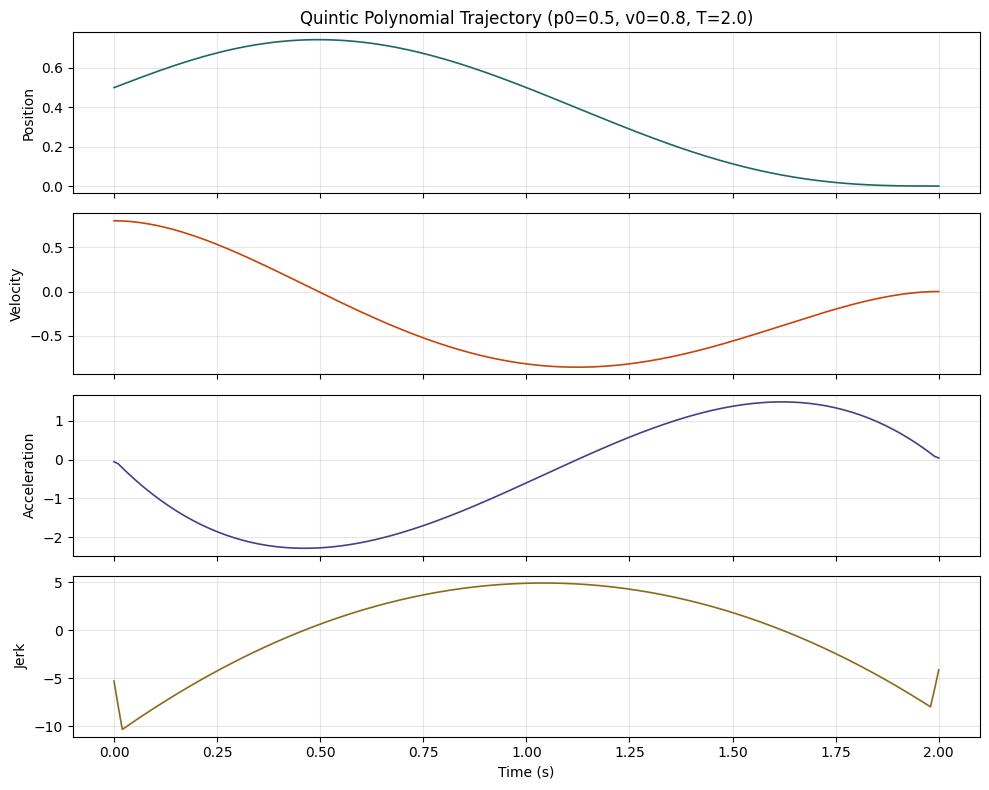

Peak |jerk| (analytical): 10.950


In [2]:
p0, v0, T = 0.5, 0.8, 2.0
coeffs = quintic_coeffs(p0, 0.0, v0, T)

t = np.linspace(0, T, 200)
pos = np.array([sum(c * ti**i for i, c in enumerate(coeffs)) for ti in t])
vel = np.gradient(pos, t)
acc = np.gradient(vel, t)
jerk = np.gradient(acc, t)

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
for ax, data, label, color in zip(
    axes,
    [pos, vel, acc, jerk],
    ["Position", "Velocity", "Acceleration", "Jerk"],
    ["#1a6b5e", "#c8440a", "#4a3d8c", "#8c6a1a"],
):
    ax.plot(t, data, color=color, linewidth=1.2)
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)

axes[0].set_title(f"Quintic Polynomial Trajectory (p0={p0}, v0={v0}, T={T})")
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

print(f"Peak |jerk| (analytical): {max(abs(compute_jerk(coeffs, ti)) for ti in t):.3f}")

## 2. Run the planner on CartPole-v1

Run 10 episodes and collect position traces to verify the controller and metric pipeline.

In [3]:
env = gym.make("CartPole-v1")
planner = QuinticPlanner(T=2.0, dt=0.02)

all_positions = []
all_metrics = []

for ep in range(10):
    obs, _ = env.reset(seed=ep)
    planner.reset(obs)
    positions = []
    spike_counts = []
    done = False

    while not done:
        action, sc = planner(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        positions.append(float(obs[0]))
        spike_counts.append(sc)
        done = terminated or truncated

    all_positions.append(positions)
    metrics = log_episode("quintic", positions, sum(spike_counts), flop_count=20)
    all_metrics.append(metrics)
    print(f"Ep {ep}: steps={len(positions)}, peak_jerk={metrics['peak_jerk']:.3f}, "
          f"endpoint_err={metrics['endpoint_err']:.4f}, osc_amp={metrics['osc_amp']:.4f}")

env.close()

Ep 0: steps=28, peak_jerk=304.629, endpoint_err=0.0075, osc_amp=0.0056
Ep 1: steps=50, peak_jerk=243.925, endpoint_err=0.0130, osc_amp=0.0074
Ep 2: steps=52, peak_jerk=243.931, endpoint_err=0.0106, osc_amp=0.0120
Ep 3: steps=43, peak_jerk=243.890, endpoint_err=0.0177, osc_amp=0.0094
Ep 4: steps=32, peak_jerk=304.652, endpoint_err=0.0361, osc_amp=0.0041
Ep 5: steps=53, peak_jerk=243.979, endpoint_err=0.0091, osc_amp=0.0098
Ep 6: steps=45, peak_jerk=304.855, endpoint_err=0.0085, osc_amp=0.0038
Ep 7: steps=37, peak_jerk=304.804, endpoint_err=0.0180, osc_amp=0.0025
Ep 8: steps=82, peak_jerk=243.960, endpoint_err=0.0319, osc_amp=0.0077
Ep 9: steps=43, peak_jerk=304.996, endpoint_err=0.0212, osc_amp=0.0044


## 3. Visualise position traces across episodes

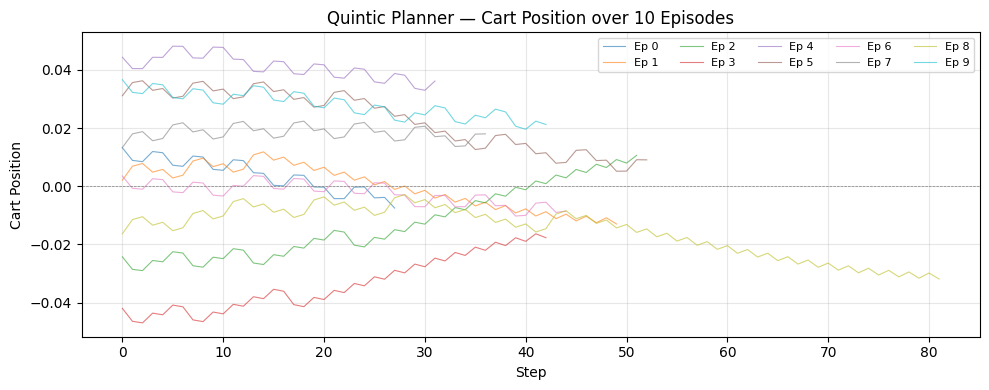

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
for i, pos_trace in enumerate(all_positions):
    ax.plot(pos_trace, alpha=0.6, linewidth=0.8, label=f"Ep {i}")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
ax.set_xlabel("Step")
ax.set_ylabel("Cart Position")
ax.set_title("Quintic Planner — Cart Position over 10 Episodes")
ax.legend(fontsize=8, ncol=5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Jerk profile for a single episode

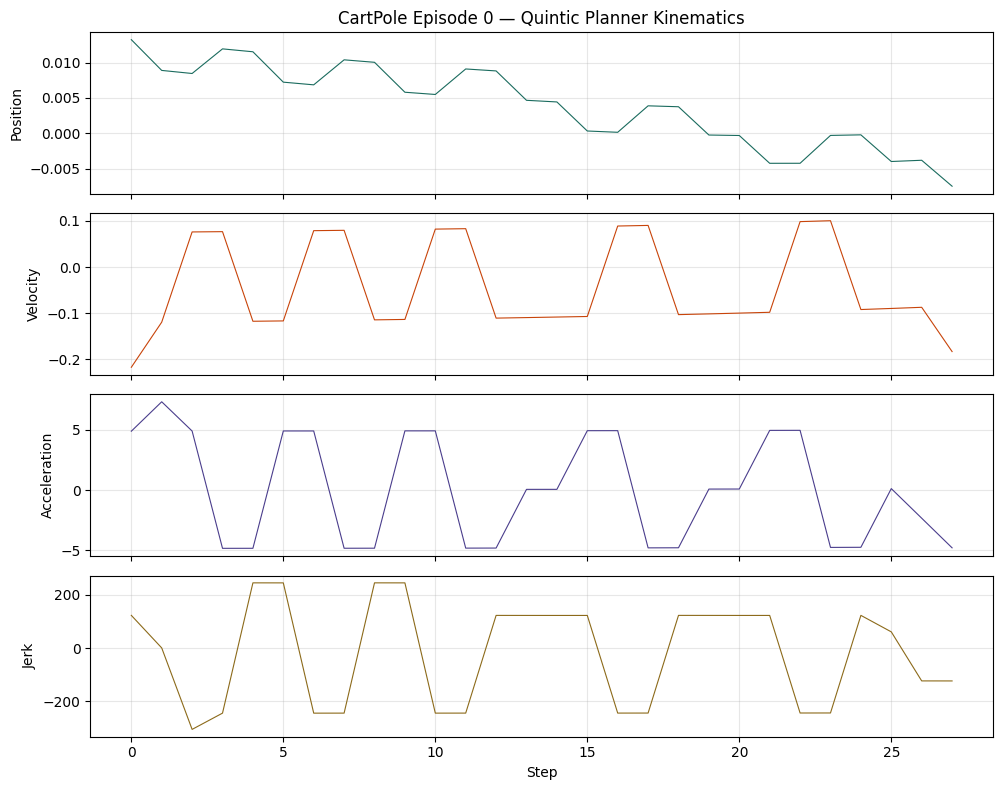

Peak |jerk|: 304.629


In [5]:
ep_idx = 0
pos_arr = np.array(all_positions[ep_idx])
dt = 0.02
vel_arr = np.gradient(pos_arr, dt)
acc_arr = np.gradient(vel_arr, dt)
jerk_arr = np.gradient(acc_arr, dt)

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
for ax, data, label, color in zip(
    axes,
    [pos_arr, vel_arr, acc_arr, jerk_arr],
    ["Position", "Velocity", "Acceleration", "Jerk"],
    ["#1a6b5e", "#c8440a", "#4a3d8c", "#8c6a1a"],
):
    ax.plot(data, color=color, linewidth=0.8)
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)

axes[0].set_title(f"CartPole Episode {ep_idx} — Quintic Planner Kinematics")
axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()

print(f"Peak |jerk|: {np.max(np.abs(jerk_arr)):.3f}")

## 5. Metric summary

These are the baseline numbers for the paper's Table 1.

In [6]:
import pandas as pd

df = pd.DataFrame(all_metrics)
print("Quintic Planner — 10 episodes")
print("=" * 50)
for col in ["peak_jerk", "endpoint_err", "osc_amp"]:
    print(f"  {col:15s}: {df[col].mean():.4f} ± {df[col].std():.4f}")
print(f"  {'flops':15s}: {df['flops'].mean():.0f} (analytical, constant)")

Quintic Planner — 10 episodes
  peak_jerk      : 274.3621 ± 32.0710
  endpoint_err   : 0.0174 ± 0.0099
  osc_amp        : 0.0067 ± 0.0031
  flops          : 20 (analytical, constant)


## Next Steps

With baseline numbers established, proceed to:
- **Phase 2**: Build the SNN controller (`model.py` SNNController class)
- **train.py**: Train on CartPole with surrogate gradient + STDP
- **Phase 3**: Run the full 100-episode benchmark and compare all three controllers